# Notebook 02 — SAE Training
Trains one SAE per layer (layers 4 and 12). Logs MSE, L0, dead features every 1k steps.
Target L0: 5–50 active features per token. Adjust alpha if outside this range.

In [1]:
import sys, os
sys.path.insert(0, '..')
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from src.sae import SAE

DEVICE    = 'cuda'
D_INPUT   = 768
D_HIDDEN  = 3072
ALPHA     = 5e-3  # L0 target: 5-50; increase if L0 > 50, decrease if L0 < 2
LR        = 1e-4
BATCH     = 2048
N_STEPS   = 100_000
LOG_EVERY = 1_000
os.makedirs('../checkpoints', exist_ok=True)

In [2]:
def train_sae(acts_path: str, save_path: str, label: str) -> dict:
    acts = torch.load(acts_path, weights_only=False)  # 保留在 CPU

    acts_mean = acts.mean(dim=0)
    acts = acts - acts_mean
    acts_rms = acts.pow(2).mean().sqrt()
    acts = acts / acts_rms

    loader = DataLoader(TensorDataset(acts), batch_size=BATCH, shuffle=True, drop_last=True)

    sae = SAE(d_input=D_INPUT, d_hidden=D_HIDDEN, alpha=ALPHA).to(DEVICE)
    opt = torch.optim.Adam(sae.parameters(), lr=LR)

    log = {k: [] for k in ('step', 'total', 'mse', 'l1', 'l0', 'dead_pct')}
    step = 0

    while step < N_STEPS:
        for (x,) in loader:
            if step >= N_STEPS:
                break
            x = x.to(DEVICE)  # 每个 batch 才搬上 GPU
            f, x_hat = sae(x)
            total, mse, l1 = sae.loss(x, f, x_hat)
            opt.zero_grad(); total.backward(); opt.step()
            sae.normalize_decoder()

            if step % LOG_EVERY == 0:
                with torch.no_grad():
                    l0       = (f > 0).float().sum(dim=1).mean().item()
                    dead_pct = ((f > 0).float().sum(dim=0) == 0).float().mean().item() * 100
                log['step'].append(step)
                log['total'].append(total.item())
                log['mse'].append(mse.item())
                log['l1'].append(l1.item())
                log['l0'].append(l0)
                log['dead_pct'].append(dead_pct)
                print(f'[{label}] step={step:6d} | mse={mse.item():.4f} | '
                      f'l0={l0:.1f} | dead={dead_pct:.1f}%')
            step += 1

    torch.save({'state_dict': sae.state_dict(), 'log': log,
                'acts_mean': acts_mean.cpu(), 'acts_rms': acts_rms.cpu()}, save_path)
    print(f'Saved {save_path}')
    return log

In [3]:
log4 = train_sae('../data/layer4_activations.pt', '../checkpoints/sae_layer4.pt', 'layer4')

[layer4] step=     0 | mse=1.1787 | l0=1534.4 | dead=0.0%
[layer4] step=  1000 | mse=0.6190 | l0=117.3 | dead=0.0%
[layer4] step=  2000 | mse=0.5123 | l0=86.9 | dead=24.9%
[layer4] step=  3000 | mse=0.4897 | l0=72.6 | dead=71.1%
[layer4] step=  4000 | mse=0.4749 | l0=61.9 | dead=76.3%
[layer4] step=  5000 | mse=0.4610 | l0=55.8 | dead=76.4%
[layer4] step=  6000 | mse=0.4557 | l0=51.7 | dead=76.3%
[layer4] step=  7000 | mse=0.4512 | l0=49.0 | dead=76.2%
[layer4] step=  8000 | mse=0.4498 | l0=47.9 | dead=76.0%
[layer4] step=  9000 | mse=0.4450 | l0=47.2 | dead=75.8%
[layer4] step= 10000 | mse=0.4451 | l0=46.9 | dead=75.6%
[layer4] step= 11000 | mse=0.4434 | l0=47.0 | dead=75.3%
[layer4] step= 12000 | mse=0.4391 | l0=46.5 | dead=74.9%
[layer4] step= 13000 | mse=0.4425 | l0=47.2 | dead=74.6%
[layer4] step= 14000 | mse=0.4373 | l0=46.9 | dead=74.5%
[layer4] step= 15000 | mse=0.4356 | l0=46.6 | dead=74.0%
[layer4] step= 16000 | mse=0.4393 | l0=48.1 | dead=73.3%
[layer4] step= 17000 | mse=0.4

In [3]:
log12 = train_sae('../data/layer12_activations.pt', '../checkpoints/sae_layer12.pt', 'layer12')

[layer12] step=     0 | mse=1.1887 | l0=1536.1 | dead=0.0%
[layer12] step=  1000 | mse=0.7460 | l0=94.8 | dead=0.0%
[layer12] step=  2000 | mse=0.6415 | l0=54.3 | dead=6.1%
[layer12] step=  3000 | mse=0.6129 | l0=46.6 | dead=12.3%
[layer12] step=  4000 | mse=0.5845 | l0=39.3 | dead=67.0%
[layer12] step=  5000 | mse=0.5600 | l0=34.8 | dead=67.9%
[layer12] step=  6000 | mse=0.5488 | l0=31.9 | dead=69.0%
[layer12] step=  7000 | mse=0.5444 | l0=31.0 | dead=67.5%
[layer12] step=  8000 | mse=0.5297 | l0=30.3 | dead=65.3%
[layer12] step=  9000 | mse=0.5241 | l0=30.6 | dead=62.8%
[layer12] step= 10000 | mse=0.5150 | l0=30.9 | dead=60.1%
[layer12] step= 11000 | mse=0.5118 | l0=31.7 | dead=57.6%
[layer12] step= 12000 | mse=0.5061 | l0=32.0 | dead=55.0%
[layer12] step= 13000 | mse=0.4964 | l0=32.8 | dead=52.1%
[layer12] step= 14000 | mse=0.4896 | l0=33.4 | dead=49.9%
[layer12] step= 15000 | mse=0.4867 | l0=34.7 | dead=46.9%
[layer12] step= 16000 | mse=0.4838 | l0=34.6 | dead=45.0%
[layer12] step=

In [ ]:
ckpt4  = torch.load('../checkpoints/sae_layer4.pt',  weights_only=False)
ckpt12 = torch.load('../checkpoints/sae_layer12.pt', weights_only=False)
log4  = ckpt4['log']
log12 = ckpt12['log']

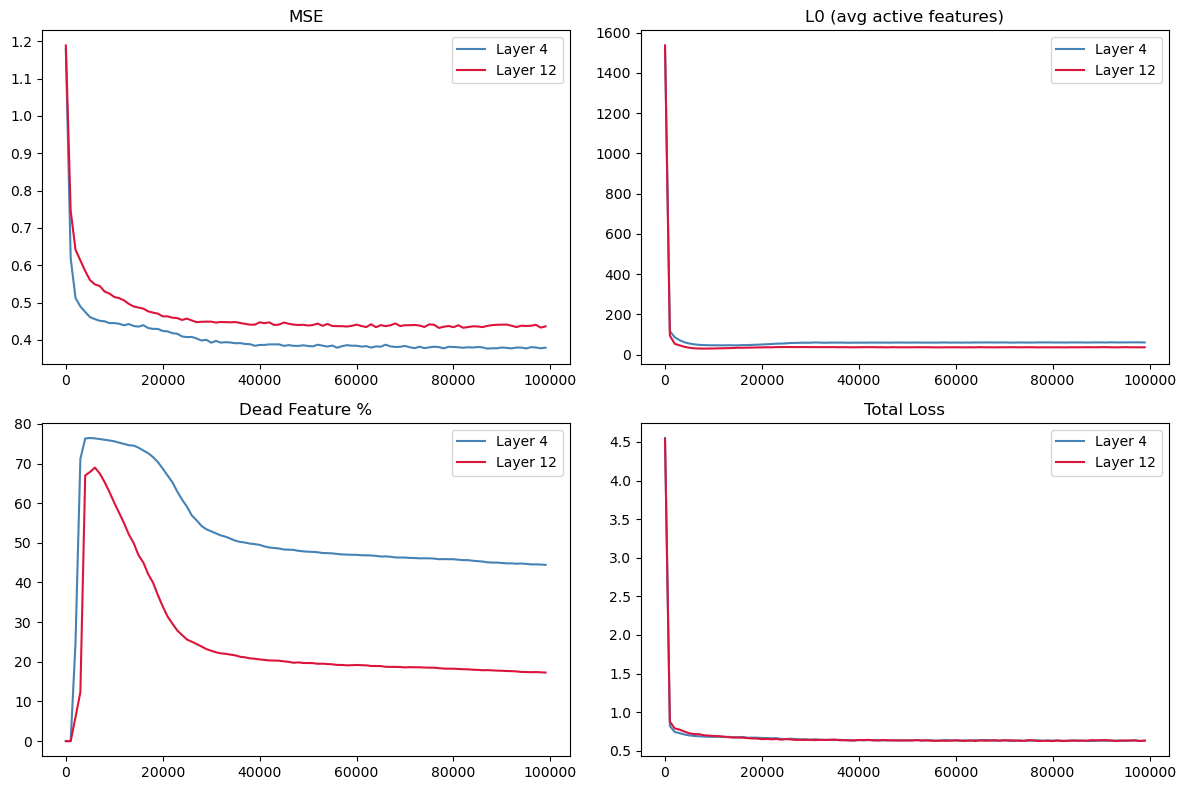

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for log, label, color in [(log4, 'Layer 4', 'steelblue'), (log12, 'Layer 12', 'crimson')]:
    s = log['step']
    axes[0,0].plot(s, log['mse'],      label=label, color=color)
    axes[0,1].plot(s, log['l0'],       label=label, color=color)
    axes[1,0].plot(s, log['dead_pct'], label=label, color=color)
    axes[1,1].plot(s, log['total'],    label=label, color=color)
for ax, title in zip(axes.flat, ['MSE', 'L0 (avg active features)', 'Dead Feature %', 'Total Loss']):
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.savefig('../checkpoints/training_curves.png', dpi=150)
plt.show()